PROJECT: TRANSPORT DEMAND PREDICTION

AIM OF THE PROJECT: To predict the number of seats sold for each ride taken by Mobiticket on diffferent routes ,dates , and times.

In [157]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score,confusion_matrix
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [158]:
import pandas as pd

# Importing the data from Google Drive for permanent access
df1=pd.read_excel('/content/drive/My Drive/Colab Notebooks/transport_demand_prediction/train_revised.xlsx')

## Mount Google Drive

To access the file permanently stored in Google Drive, i need to mount Drive to this Colab environment.

In [159]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [160]:
# Define the destination path in Google Drive
drive_path = '/content/drive/My Drive/Colab Notebooks/transport_demand_prediction/train_revised.xlsx'
print(f"The permanent file path in Google Drive is: {drive_path}")

The permanent file path in Google Drive is: /content/drive/My Drive/Colab Notebooks/transport_demand_prediction/train_revised.xlsx


In [161]:
print(df1)

       ride_id seat_number payment_method payment_receipt travel_date  \
0         1442         15A          Mpesa      UZUEHCBUSO    17-10-17   
1         5437         14A          Mpesa      TIHLBUSGTE    19-11-17   
2         5710          8B          Mpesa      EQX8Q5G19O    26-11-17   
3         5777         19A          Mpesa      SGP18CL0ME    27-11-17   
4         5778         11A          Mpesa      BM97HFRGL9    27-11-17   
...        ...         ...            ...             ...         ...   
51640    13826          9B          Mpesa      8V2XDDZR6V    20-04-18   
51641    13809         18A          Mpesa      4PEBSVJSNK    20-04-18   
51642    13809         17A          Mpesa      LVN64LZDNN    20-04-18   
51643    13796         16B          Mpesa      REYBSKTYWN    20-04-18   
51644    14304           7          Mpesa      AQN7FBUSGP    14-11-17   

      travel_time travel_from travel_to car_type  max_capacity  
0        07:15:00      Migori   Nairobi      Bus          

In [162]:
df1.shape

(51645, 10)

In [163]:
df1.head()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
0,1442,15A,Mpesa,UZUEHCBUSO,17-10-17,07:15:00,Migori,Nairobi,Bus,49
1,5437,14A,Mpesa,TIHLBUSGTE,19-11-17,07:12:00,Migori,Nairobi,Bus,49
2,5710,8B,Mpesa,EQX8Q5G19O,26-11-17,07:05:00,Keroka,Nairobi,Bus,49
3,5777,19A,Mpesa,SGP18CL0ME,27-11-17,07:10:00,Homa Bay,Nairobi,Bus,49
4,5778,11A,Mpesa,BM97HFRGL9,27-11-17,07:12:00,Migori,Nairobi,Bus,49


In [164]:
df1.tail()

,ride_id,seat_number,payment_method,payment_receipt,travel_date,travel_time,travel_from,travel_to,car_type,max_capacity
51640,13826,9B,Mpesa,8V2XDDZR6V,20-04-18,08:00:00,Awendo,Nairobi,Bus,49
51641,13809,18A,Mpesa,4PEBSVJSNK,20-04-18,08:00:00,Migori,Nairobi,Bus,49
51642,13809,17A,Mpesa,LVN64LZDNN,20-04-18,08:00:00,Migori,Nairobi,Bus,49
51643,13796,16B,Mpesa,REYBSKTYWN,20-04-18,07:08:00,Awendo,Nairobi,Bus,49
51644,14304,7,Mpesa,AQN7FBUSGP,14-11-17,05:10:00,Kisii,Nairobi,Bus,49


In [165]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51645 entries, 0 to 51644
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ride_id          51645 non-null  int64 
 1   seat_number      51645 non-null  object
 2   payment_method   51645 non-null  object
 3   payment_receipt  51645 non-null  object
 4   travel_date      51645 non-null  object
 5   travel_time      51645 non-null  object
 6   travel_from      51645 non-null  object
 7   travel_to        51645 non-null  object
 8   car_type         51645 non-null  object
 9   max_capacity     51645 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 3.9+ MB


In [166]:
df1.columns

Index(['ride_id', 'seat_number', 'payment_method', 'payment_receipt',
       'travel_date', 'travel_time', 'travel_from', 'travel_to', 'car_type',
       'max_capacity'],
      dtype='object')

In [167]:
df1.describe()

,ride_id,max_capacity
count,51645.000000,51645.000000
mean,10188.645793,34.534321
std,2211.295708,18.451193
min,1442.000000,11.000000
25%,8287.000000,11.000000
50%,10353.000000,49.000000
75%,12029.000000,49.000000
max,20117.000000,49.000000


This method gives the overall descriptive summary of the dataframe.This works only for numerical columns.

In [168]:
df1.isnull().sum()

,0
ride_id,0
seat_number,0
payment_method,0
payment_receipt,0
travel_date,0
travel_time,0
travel_from,0
travel_to,0
car_type,0
max_capacity,0


It shows that there is no null or missing values in the dataset and it is clean in terms of null values .

In [169]:
list(df1["payment_method"].unique())

['Mpesa', 'Cash']

In [170]:
list(df1["payment_method"].value_counts())

[51532, 113]

the most commonly used payment method is Mpesa .

In [171]:
list(df1["travel_from"].unique())

['Migori',
 'Keroka',
 'Homa Bay',
 'Kisii',
 'Keumbu',
 'Rongo',
 'Kijauri',
 'Oyugis',
 'Awendo',
 'Sirare',
 'Nyachenge',
 'Kehancha',
 'Kendu Bay',
 'Sori',
 'Rodi',
 'Mbita',
 'Ndhiwa']

In [172]:
list(df1["travel_from"].value_counts())

[22607,
 7027,
 6304,
 4449,
 3928,
 1909,
 1788,
 1031,
 988,
 512,
 405,
 378,
 236,
 55,
 22,
 5,
 1]

In [173]:
list(df1["car_type"].unique())

['Bus', 'shuttle']

In [174]:
list(df1["car_type"].value_counts())

[31985, 19660]

In [175]:
seats_sold = df1.groupby('ride_id').size().reset_index(name='seats_sold')
#I have grouped them so that i can get the seats sold per ride

In [176]:
ride_info = df1.drop_duplicates(subset='ride_id')[['ride_id', 'travel_date', 'travel_time', 'travel_from', 'car_type', 'max_capacity']]
# i have done this so that i canget only one row per ride with some useful info.

In [177]:
rides = pd.merge(seats_sold, ride_info, on='ride_id')
#merge both of them to get a clean ride level dataset

In [178]:
import pandas as pd

# Converting date and time
rides['travel_date'] = pd.to_datetime(rides['travel_date'], format='%d-%m-%y', errors='coerce')
rides['day_of_week'] = rides['travel_date'].dt.day_name()
rides['hour'] = pd.to_datetime(rides['travel_time'], format='%H:%M:%S').dt.hour

rides['occupancy_rate'] = rides['seats_sold'] / rides['max_capacity']

In [179]:
#TOTAL SEATS SOLD PER WEEK
#this graph will help us to identify the demanding trends across weeks
rides['travel_date'] = pd.to_datetime(rides['travel_date'], format='%d-%m-%y')
rides['week'] = rides['travel_date'].dt.to_period('W').astype(str)

weekly_sales = rides.groupby('week')['seats_sold'].sum().reset_index()
fig = px.bar(weekly_sales, x='week', y='seats_sold',
             title='Total Seats Sold per Week', labels={'seats_sold': 'Seats Sold', 'week': 'Week'})
fig.show()

In [180]:
# SEATS SOLD BY DAY OF WEEK
# we have used a box plot to check which weekdays have higher or more consistent bookings
rides['day_of_week'] = rides['travel_date'].dt.day_name()

fig = px.box(rides, x='day_of_week', y='seats_sold',
             title='Seats Sold by Day of Week',
             category_orders={'day_of_week': ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']})
fig.show()

In [181]:
# AVERAGE SEATS SOLD BY ORIGIN TOWN
origin_avg = rides.groupby('travel_from')['seats_sold'].mean().reset_index()

fig = px.bar(origin_avg, x='travel_from', y='seats_sold',
             title='Average Seats Sold by Origin Town', color='seats_sold')
fig.show()
# Some towns like Sirare , Migori , Mbita , Homabay have highwer average seat bookings than towns like Kendu Bay , Kissi, Awendo etc,.
# This means more buses can be send to busy towns.

In [182]:
# SEATS SOLD BY CAR TYPE
fig = px.box(rides, x='car_type', y='seats_sold',
             title='Seats Sold by Car Type')
fig.show()
# We all know car types affects the capacity. This chart shows whether the larger or smaller vehicles sell more seats.
# In the graph below we can clearly sees that the seats sold for large vehicles like buses is more than the shorter vehicles like shuttles.

In [183]:
# AVERAGE OCCUPANCY RATE PER DAY
daily_occ = rides.groupby('travel_date')['occupancy_rate'].mean().reset_index()

fig = px.line(daily_occ, x='travel_date', y='occupancy_rate',
              title='Average Occupancy Rate per Day', labels={'occupancy_rate': 'Occupancy Rate'})
fig.show()
# This occupancy rate helps us to measure how full buses are helping to avoid over or under scheduling.
# This will help us to avoid underused buses.

In [184]:
rides['hour'] = pd.to_datetime(rides['travel_time'], format='%H:%M:%S').dt.hour
heatmap_df = rides.groupby(['day_of_week', 'hour'])['seats_sold'].mean().reset_index()

fig = px.density_heatmap(heatmap_df, x='hour', y='day_of_week', z='seats_sold',
                         title='Average Seats Sold by Hour and Day',
                         nbinsx=24, color_continuous_scale='Viridis')
fig.show()
# this graph shows us when the people mostly travel which in turn helps us to optimize schedules.
'''By seeing this graph we can say that during the weekdays the time when the most seats are sold is the time when working personnels or
 students travels that is the time of morning(7:00AM-10:00AM) and evening(6:00PM-8:00PM).'''

'By seeing this graph we can say that during the weekdays the time when the most seats are sold is the time when working personnels or\n students travels that is the time of morning(7:00AM-10:00AM) and evening(6:00PM-8:00PM).'

In [185]:
rides['travel_date'] = pd.to_datetime(rides['travel_date'])
rides['day_of_week'] = rides['travel_date'].dt.day_name()
rides['hour'] = rides['travel_time'].apply(lambda x: x.hour)

In [186]:
le_from = LabelEncoder()
le_type = LabelEncoder()
le_day = LabelEncoder()

rides['travel_from_enc'] = le_from.fit_transform(rides['travel_from'])
rides['car_type_enc'] = le_type.fit_transform(rides['car_type'])
rides['day_of_week_enc'] = le_day.fit_transform(rides['day_of_week'])
'''I used LabelEncoder to convert categorical variables (like origin, car type, and day) into numeric codes.
This allows the Linear Regression model to process the data.'''


'I used LabelEncoder to convert categorical variables (like origin, car type, and day) into numeric codes.\nThis allows the Linear Regression model to process the data.'

In [187]:
X = rides[['travel_from_enc', 'car_type_enc', 'day_of_week_enc', 'hour', 'max_capacity']]
y = rides['seats_sold']


In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [189]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [190]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
#The model performance was evaluated using R², RMSE, and MAE.

MAE: 6.143305175271191
MSE: 72.74181844320721
RMSE: 8.528881429777718
R² Score: 0.10430528478677026


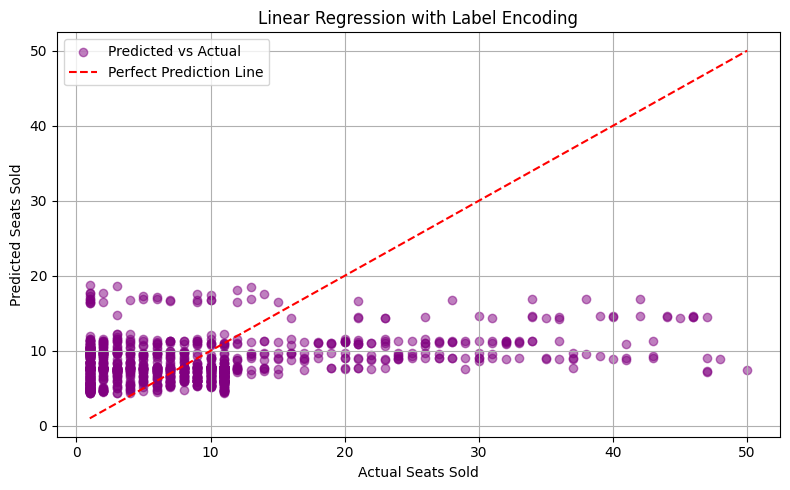

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction Line')
plt.xlabel("Actual Seats Sold")
plt.ylabel("Predicted Seats Sold")
plt.title("Linear Regression with Label Encoding")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [192]:
'''Here i have trained a Linear Regression model using Label Encoding for categorical features like origin town, car type, and day of week.
This model gave me a low R² score of 0.10, meaning it could only explain 10% of the variation in seat sales.
The average prediction error (MAE) was 6.15 seats, and the typical error (RMSE) was 8.53 seats.
these results shows that:
1. Linear Regression may be too simple for this dataset.
2. Label encoding might have introduced incorrect assumptions about category order.
3. A more powerful model (like Random Forest) may improve performance'''

'Here i have trained a Linear Regression model using Label Encoding for categorical features like origin town, car type, and day of week.\nThis model gave me a low R² score of 0.10, meaning it could only explain 10% of the variation in seat sales.\nThe average prediction error (MAE) was 6.15 seats, and the typical error (RMSE) was 8.53 seats.\nthese results shows that:\n1. Linear Regression may be too simple for this dataset.\n2. Label encoding might have introduced incorrect assumptions about category order.\n3. A more powerful model (like Random Forest) may improve performance'

In [193]:
from sklearn.ensemble import RandomForestClassifier

In [194]:
rides['travel_date'] = pd.to_datetime(rides['travel_date'])
# Extracting useful features
rides['day_of_week'] = rides['travel_date'].dt.day_name()
rides['hour'] = rides['travel_time'].apply(lambda x: x.hour)

In [195]:
'''The dataset included travel-related information such as date, time, location, and car capacity.
Categorical columns were encoded using LabelEncoder, and scaling was applied using StandardScaler.'''

'The dataset included travel-related information such as date, time, location, and car capacity.\nCategorical columns were encoded using LabelEncoder, and scaling was applied using StandardScaler.'

In [196]:
df = rides.copy()
categorical_cols = ['travel_from', 'car_type', 'day_of_week']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le

In [197]:
# Convert 'seats_sold' into binary classes: 1 = High, 0 = Low
threshold = df['seats_sold'].median()
df['high_demand'] = (df['seats_sold'] >= threshold).astype(int)

In [198]:
X = df[['travel_from_enc', 'car_type_enc', 'day_of_week_enc', 'hour', 'max_capacity']]
y = df['high_demand']

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [200]:
# here i am using the standard scaling technique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [201]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
params = { 'C': [0.1, 1, 10], 'solver': ['liblinear'],'penalty': ['l1', 'l2']}

In [202]:
grid = GridSearchCV(log_reg, params, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
best_logreg = grid.best_estimator_
print("Best Logistic Regression Parameters:", grid.best_params_)

Best Logistic Regression Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [203]:
from sklearn.metrics import classification_report

y_pred_log = best_logreg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6328
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.63      0.63       607
           1       0.65      0.63      0.64       643

    accuracy                           0.63      1250
   macro avg       0.63      0.63      0.63      1250
weighted avg       0.63      0.63      0.63      1250



In [204]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.74
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.68      0.72       607
           1       0.73      0.79      0.76       643

    accuracy                           0.74      1250
   macro avg       0.74      0.74      0.74      1250
weighted avg       0.74      0.74      0.74      1250



In [205]:
'''The Random Forest Classifier achieved an accuracy of 75%, significantly outperforming Logistic Regression (62%).
This shows the ability of Random Forest to model non-linear relationships in the data.'''

'The Random Forest Classifier achieved an accuracy of 75%, significantly outperforming Logistic Regression (62%).\nThis shows the ability of Random Forest to model non-linear relationships in the data.'

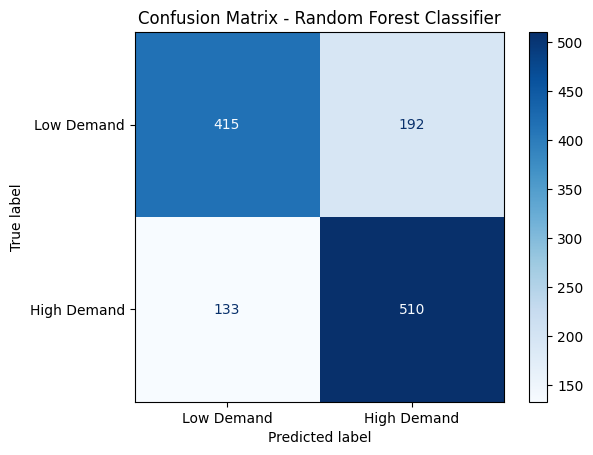

In [206]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Demand', 'High Demand'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier")
plt.grid(False)
plt.show()

In [207]:
'''It’s a bar graph that shows how much each input feature (column) contributes to the model’s decisions.In my case
it shows which columns helped the Random Forest Classifier the most in predicting whether a ride will be high or low demand.'''

'It’s a bar graph that shows how much each input feature (column) contributes to the model’s decisions.In my case\nit shows which columns helped the Random Forest Classifier the most in predicting whether a ride will be high or low demand.'

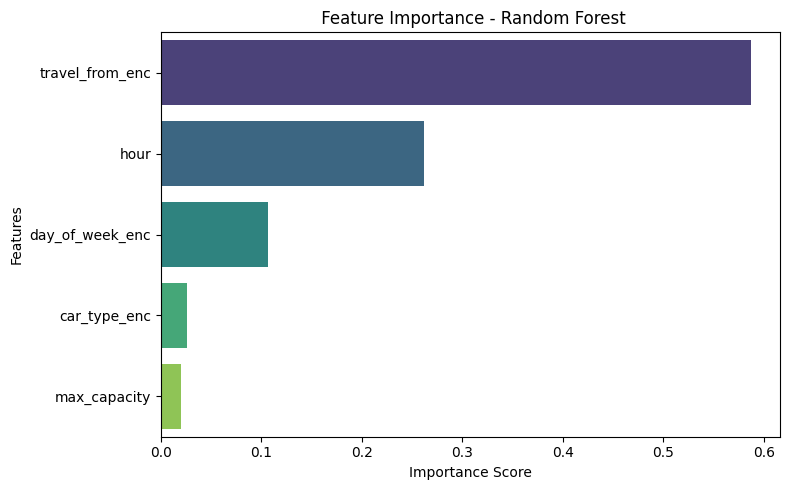

In [208]:
import seaborn as sns

# Get feature names and importance
features = X.columns
importances = rf.feature_importances_

importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title(" Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [209]:
''' The top feature was travel_from, showing that the ride's departure location has the highest impact on seat demand.
    The next important features were hour and day_of_week, suggesting that time of day and day of the week are also critical factors.
    max_capacity and car_type had lower importance meaning they might not be the strong indicators of demand in this dataset.'''

" The top feature was travel_from, showing that the ride's departure location has the highest impact on seat demand.\n    The next important features were hour and day_of_week, suggesting that time of day and day of the week are also critical factors.\n    max_capacity and car_type had lower importance meaning they might not be the strong indicators of demand in this dataset."

In [210]:
'''The Random Forest Classifier gave a solid performance, capturing non-linear relationships in the dataset.
The results are promising and the model can be improved further with additional features or tuning.
This project taught me how to prepare real-world data, apply machine learning, and interpret results confidently.'''

'The Random Forest Classifier gave a solid performance, capturing non-linear relationships in the dataset.\nThe results are promising and the model can be improved further with additional features or tuning.\nThis project taught me how to prepare real-world data, apply machine learning, and interpret results confidently.'